# Cross-method comparison (BCI IV-2a LOSO)

Aggregate every `Results/<Method>/*_loso_metrics.csv` produced by the per-method notebooks, build summary tables, and plot RMSE / Pearson / R² versus `n_input_channels` plus a band-RMSE heatmap.

Run this **after** all method notebooks have written their CSVs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != 'new_repository' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if REPO_ROOT.name != 'new_repository':
    raise RuntimeError('Run from inside new_repository tree.')

RESULTS_ROOT = REPO_ROOT / 'Results'
COMP_DIR = RESULTS_ROOT / 'Comparison'
VIZ_DIR = REPO_ROOT / 'Results_Visualization' / 'Comparison'
COMP_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print('RESULTS_ROOT =', RESULTS_ROOT)
print('COMP_DIR     =', COMP_DIR)
print('VIZ_DIR      =', VIZ_DIR)

RESULTS_ROOT = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results
COMP_DIR     = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Comparison
VIZ_DIR      = C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison


In [2]:
csv_paths = sorted(p for p in RESULTS_ROOT.glob('*/*_loso_metrics_all.csv') if p.parent.name != 'Comparison')

# Fallback to old format just in case some haven't been run yet
if not csv_paths:
    csv_paths = sorted(p for p in RESULTS_ROOT.glob('*/*_loso_metrics.csv') if p.parent.name != 'Comparison')

if not csv_paths:
    raise FileNotFoundError(
        f'No *_loso_metrics_all.csv found under {RESULTS_ROOT}. Run the method notebooks first.'
    )

frames = []
for p in csv_paths:
    df = pd.read_csv(p)
    df['method_folder'] = p.parent.name
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

# Important: Separate overall trial metrics from single-channel metrics
if 'channel' in all_df.columns:
    overall_df = all_df[all_df['channel'].isna()].copy()
else:
    overall_df = all_df.copy()

union_path = COMP_DIR / 'all_methods_loso_all.csv'
all_df.to_csv(union_path, index=False)
print(f'Union rows: {len(all_df)} -> {union_path}')
print(f'Overall average rows isolated: {len(overall_df)}')

Union rows: 2106 -> C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Comparison\all_methods_loso_all.csv
Overall average rows isolated: 162


In [3]:
core_metrics = ['rmse', 'mae', 'pearson_r', 'r2']
band_cols = [c for c in overall_df.columns if c.startswith('band_rmse_')]

metric_cols = [c for c in core_metrics + band_cols if c in overall_df.columns]
agg_spec = {c: ['mean', 'std'] for c in metric_cols}

# Use overall_df to avoid mixing per-channel data into the mean
summary_df = overall_df.groupby(['method_folder', 'n_input_channels'], as_index=False).agg(agg_spec)
summary_df.columns = [
    '_'.join([p for p in col if p]).strip('_') if isinstance(col, tuple) else col
    for col in summary_df.columns
]
summary_path = COMP_DIR / 'summary_by_method.csv'
summary_df.to_csv(summary_path, index=False)
print('Saved:', summary_path)
summary_df.head()

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Comparison\summary_by_method.csv


,method_folder,n_input_channels,rmse_mean,rmse_std,mae_mean,mae_std,pearson_r_mean,pearson_r_std,r2_mean,r2_std,band_rmse_delta_mean,band_rmse_delta_std,band_rmse_theta_mean,band_rmse_theta_std,band_rmse_alpha_mean,band_rmse_alpha_std,band_rmse_beta_mean,band_rmse_beta_std,band_rmse_gamma_mean,band_rmse_gamma_std
0,BEM_Dipole_Model,5,9.926633,1.335303,7.758319,1.046560,0.349515,0.049036,0.087621,0.024778,28.859060,8.949115,13.608762,6.242911,19.984395,16.549921,13.210344,4.852222,3.618477,2.972001
1,BEM_Dipole_Model,10,9.696122,1.269981,7.574508,0.993572,0.430936,0.045343,0.129312,0.031690,28.781908,8.759143,13.470294,6.153994,19.586437,15.960207,12.903967,4.766712,3.577873,2.990393
2,BEM_Dipole_Model,15,9.449888,1.303184,7.362959,1.008424,0.465578,0.076099,0.158088,0.050540,27.497572,8.290694,12.037746,5.759380,21.987017,20.336217,12.766711,4.510922,3.601888,3.046372
3,BEM_Residual,5,2.514549,0.496814,1.925582,0.380012,0.970529,0.004898,0.941697,0.009428,0.214097,0.093371,0.259615,0.117194,0.310229,0.134928,1.215873,0.500937,1.101533,0.480004
4,BEM_Residual,10,2.017770,0.324811,1.520635,0.225820,0.980932,0.003090,0.962113,0.006148,0.159378,0.076945,0.199352,0.107376,0.248682,0.131302,0.927453,0.461583,0.772294,0.385800


In [4]:
ranking = (
    overall_df.groupby('method_folder', as_index=False)['rmse']
    .mean()
    .sort_values('rmse')
    .reset_index(drop=True)
)
ranking['rank'] = np.arange(1, len(ranking) + 1)
ranking = ranking[['rank', 'method_folder', 'rmse']]
rank_path = COMP_DIR / 'method_ranking.csv'
ranking.to_csv(rank_path, index=False)
print('Saved:', rank_path)
ranking

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results\Comparison\method_ranking.csv


,rank,method_folder,rmse
0,1,Learned_BEM_Residual,2.223253
1,2,Interpolation_Residual,2.249161
2,3,BEM_Residual,2.282823
3,4,Spherical_Spline,2.932749
4,5,Distance_Weighted,3.825379
5,6,BEM_Dipole_Model,9.690881


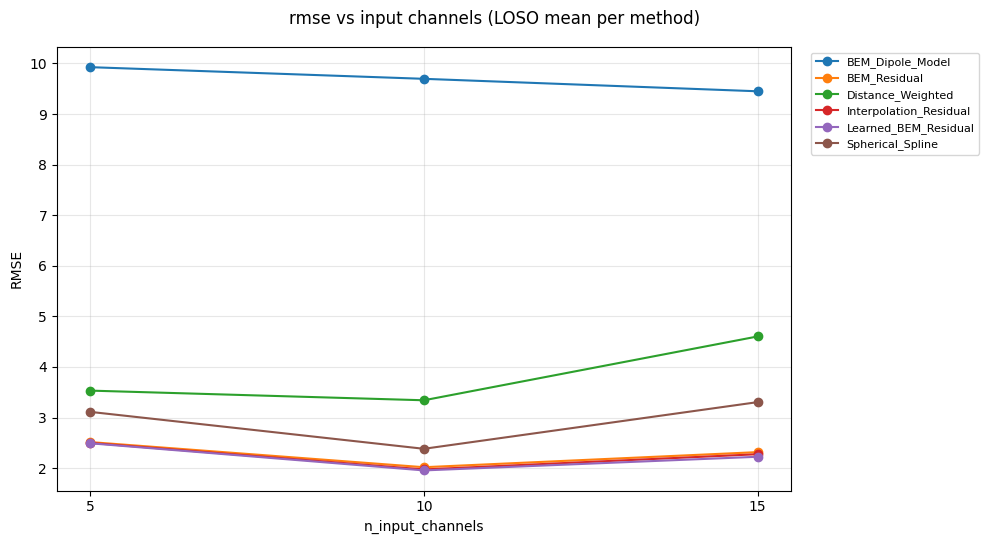

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\rmse_vs_channels.png


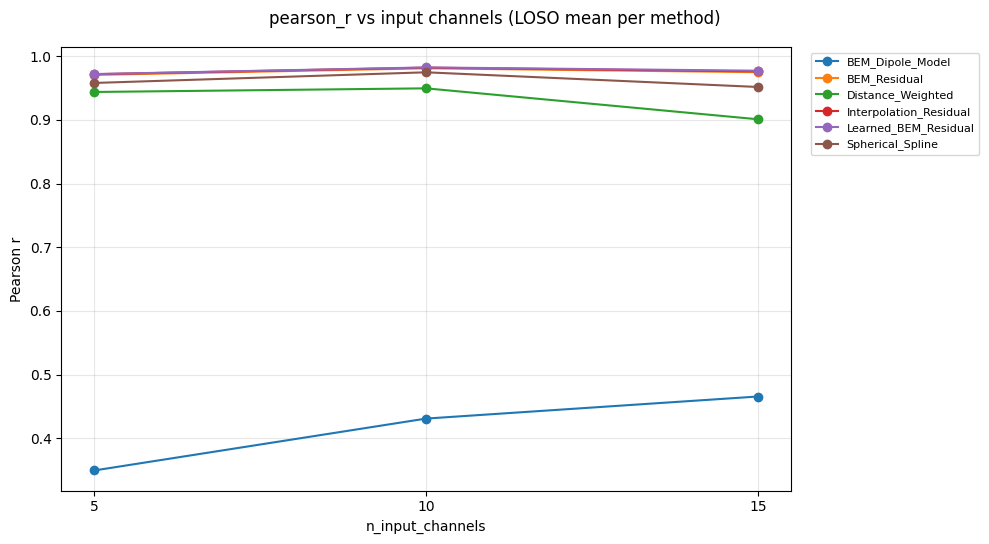

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\pearson_vs_channels.png


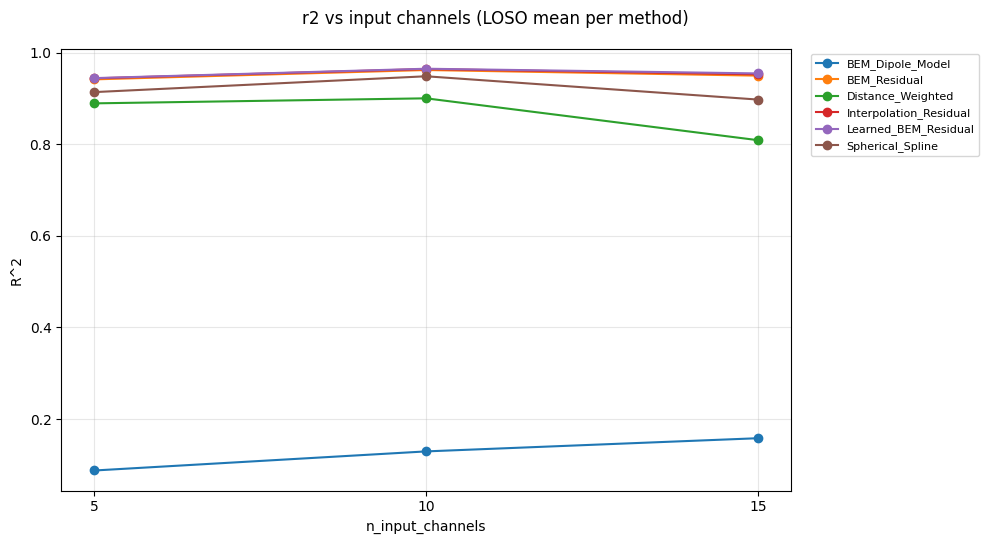

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\r2_vs_channels.png


In [5]:
def line_plot_metric(metric_key, ylabel, fname):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    methods = sorted(overall_df['method_folder'].unique())
    x_vals = sorted(overall_df['n_input_channels'].unique())
    for m in methods:
        sub = overall_df[overall_df['method_folder'] == m]
        agg = sub.groupby('n_input_channels', as_index=False)[metric_key].mean()
        ax.plot(agg['n_input_channels'], agg[metric_key], marker='o', linewidth=1.5, label=m)
    ax.set_xticks(x_vals)
    ax.set_xlabel('n_input_channels')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    fig.suptitle(f'{metric_key} vs input channels (LOSO mean per method)')
    fig.tight_layout()
    out = VIZ_DIR / fname
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)


line_plot_metric('rmse', 'RMSE', 'rmse_vs_channels.png')
line_plot_metric('pearson_r', 'Pearson r', 'pearson_vs_channels.png')
line_plot_metric('r2', 'R^2', 'r2_vs_channels.png')

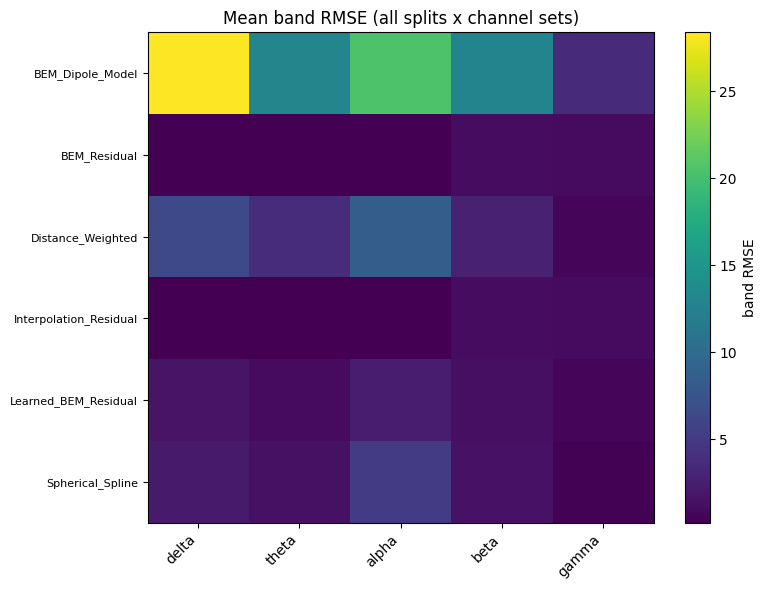

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\band_rmse_heatmap.png


In [6]:
if band_cols:
    heat = (
        overall_df.groupby('method_folder')[band_cols]
        .mean()
        .reindex(sorted(overall_df['method_folder'].unique()))
    )
    arr = heat.values.astype(np.float64)
    fig, ax = plt.subplots(figsize=(max(8, len(band_cols) * 1.2), max(6, len(heat) * 0.35)))
    im = ax.imshow(arr, aspect='auto', cmap='viridis')
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index, fontsize=8)
    ax.set_xticks(np.arange(len(band_cols)))
    ax.set_xticklabels([c.replace('band_rmse_', '') for c in band_cols], rotation=45, ha='right')
    ax.set_title('Mean band RMSE (all splits x channel sets)')
    plt.colorbar(im, ax=ax, label='band RMSE')
    fig.tight_layout()
    out = VIZ_DIR / 'band_rmse_heatmap.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)
else:
    print('No band_rmse_* columns in union; skipping heatmap.')

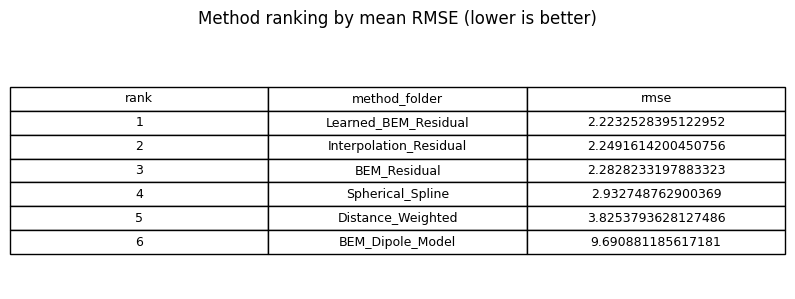

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\ranking_table.png


In [7]:
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(ranking))))
ax.axis('off')
tbl = ax.table(
    cellText=ranking.values,
    colLabels=list(ranking.columns),
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.4)
fig.suptitle('Method ranking by mean RMSE (lower is better)')
fig.tight_layout()
out = VIZ_DIR / 'ranking_table.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)

## Subject-Level Granularity

While the previous sections average the metrics across subjects to understand scaling with `n_input_channels`, the Leave-One-Subject-Out (LOSO) splits mean we inherently have the exact metrics **per subject**. 

Let's visualize the performance across individual test subjects.

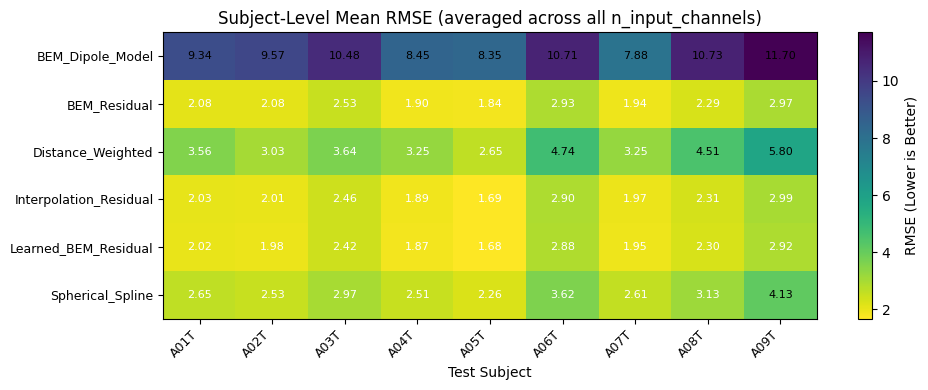

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\subject_rmse_heatmap.png


In [8]:
import seaborn as sns

# Subject-level analysis (Mean RMSE across all channel sets per subject)
subject_agg = overall_df.groupby(['method_folder', 'test_subject'])['rmse'].mean().unstack('test_subject')

fig, ax = plt.subplots(figsize=(max(10, len(subject_agg.columns)*0.6), max(4, len(subject_agg.index)*0.5)))
im = ax.imshow(subject_agg.values, aspect='auto', cmap='viridis_r')
ax.set_yticks(np.arange(len(subject_agg.index)))
ax.set_yticklabels(subject_agg.index, fontsize=9)
ax.set_xticks(np.arange(len(subject_agg.columns)))
ax.set_xticklabels(subject_agg.columns, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Test Subject')
ax.set_title('Subject-Level Mean RMSE (averaged across all n_input_channels)')
plt.colorbar(im, ax=ax, label='RMSE (Lower is Better)')

# Annotate values
for i in range(len(subject_agg.index)):
    for j in range(len(subject_agg.columns)):
        val = subject_agg.values[i, j]
        text_color = 'white' if val < subject_agg.values.mean() else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=text_color, fontsize=8)

fig.tight_layout()
out = VIZ_DIR / 'subject_rmse_heatmap.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)

C:\Users\unnat\AppData\Local\Temp\ipykernel_23776\685682489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subject_rmse_df, x='method_folder', y='rmse', order=order, ax=ax, palette='Set3')
C:\Users\unnat\AppData\Local\Temp\ipykernel_23776\685682489.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


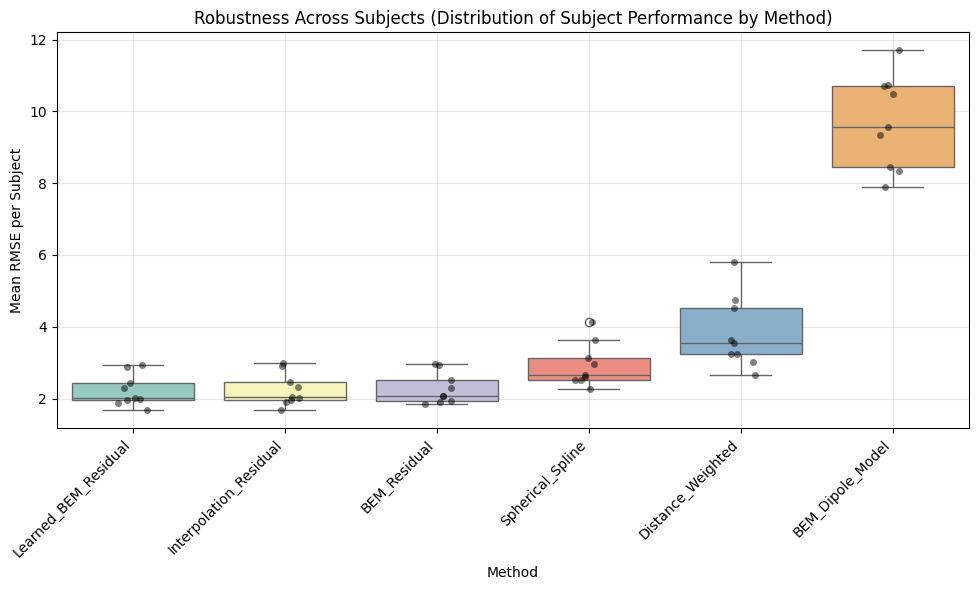

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\subject_rmse_boxplot.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Average RMSE for each subject per method
subject_rmse_df = overall_df.groupby(['method_folder', 'test_subject'], as_index=False)['rmse'].mean()

# Order categories by Median RMSE (best performing on the left)
order = subject_rmse_df.groupby('method_folder')['rmse'].median().sort_values().index

sns.boxplot(data=subject_rmse_df, x='method_folder', y='rmse', order=order, ax=ax, palette='Set3')
sns.stripplot(data=subject_rmse_df, x='method_folder', y='rmse', order=order, ax=ax, color='black', alpha=0.5)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Mean RMSE per Subject')
ax.set_xlabel('Method')
ax.set_title('Robustness Across Subjects (Distribution of Subject Performance by Method)')
ax.grid(True, alpha=0.3)

fig.tight_layout()
out = VIZ_DIR / 'subject_rmse_boxplot.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)

## Channel-Level Granularity

Since we've saved metrics down to the individual reconstructed channels in `all_df`, we can aggregate the average error *per specific missing channel* to see if some regions (e.g., Occipital vs Frontal) are systematically harder to reconstruct across the competing methods.

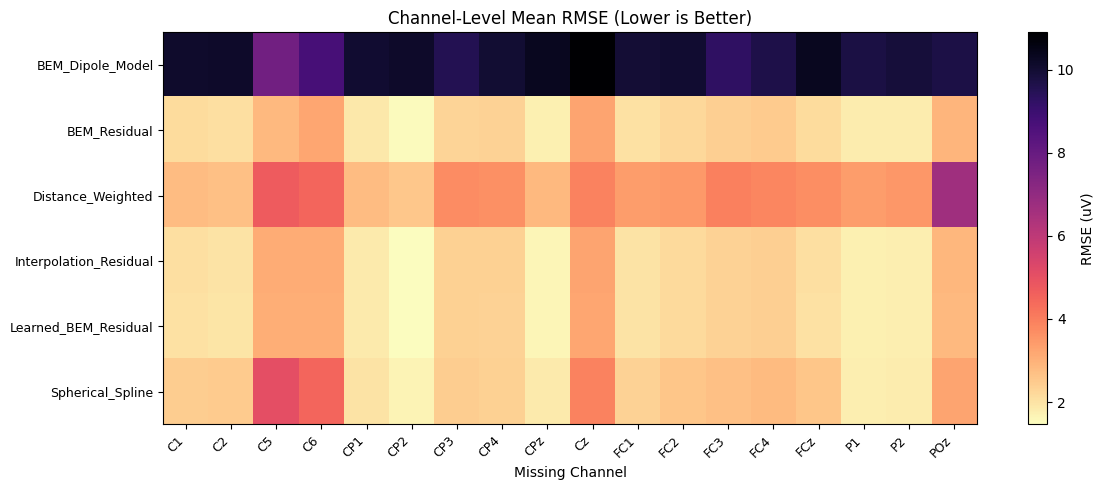

Saved: C:\Users\unnat\Documents\GitHub\EEGFeatureExtraction\new_repository\Results_Visualization\Comparison\channel_rmse_heatmap.png


In [10]:
if 'channel' in all_df.columns:
    per_ch_df = all_df[~all_df['channel'].isna()].copy()
    
    if not per_ch_df.empty:
        # Calculate mean RMSE by method and specific channel
        channel_agg = per_ch_df.groupby(['method_folder', 'channel'])['rmse'].mean().unstack('channel')
        
        # Sort channels loosely by typical front-to-back topology if possible
        ch_order = sorted(channel_agg.columns)
        channel_agg = channel_agg[ch_order]
        
        fig, ax = plt.subplots(figsize=(max(12, len(channel_agg.columns)*0.5), max(5, len(channel_agg.index)*0.5)))
        im = ax.imshow(channel_agg.values, aspect='auto', cmap='magma_r')
        
        ax.set_yticks(np.arange(len(channel_agg.index)))
        ax.set_yticklabels(channel_agg.index, fontsize=9)
        ax.set_xticks(np.arange(len(channel_agg.columns)))
        ax.set_xticklabels(channel_agg.columns, rotation=45, ha='right', fontsize=9)
        
        ax.set_xlabel('Missing Channel')
        ax.set_title('Channel-Level Mean RMSE (Lower is Better)')
        plt.colorbar(im, ax=ax, label='RMSE (uV)')
        
        fig.tight_layout()
        out = VIZ_DIR / 'channel_rmse_heatmap.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved:', out)
    else:
        print("No per-channel metrics found in the dataset.")
else:
    print("Column 'channel' does not exist in the aggregated data yet. Did you run the updated notebook scripts?")